In [34]:
import json
import os
import pprint
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
from pprint import pprint
# import display to show images in the notebook
from IPython.display import display, Image
plt.style.use(['science', 'no-latex'])

with open("/research/hal-afsharim/learn-to-steer/Hallucination/POPE/hallucination/hallucination_metrics_llava_pope_test_steer_14_yes_no_descriptive_2.2_llava_14_average_all_pope_train_-1_128_model_prediction.json", "r") as f:
    l2s_descriptive = json.load(f)

with open("/research/hal-afsharim/learn-to-steer/Hallucination/POPE/hallucination/hallucination_metrics_llava_pope_test_reparo_14_yes_no_descriptive_1_-0.004_-1_1e-2_0_spca_model_llava_14_all_pope_train_-1_100_model_prediction.json", "r") as f:
    reparo_descriptive = json.load(f)

# # with open("/research/hal-afsharim/learn-to-steer/Hallucination/POPE/hallucination/hallucination_metrics_llava_pope_test_reparo_14_yes_no_descriptive_5_-0.035_-0.04_spca_model_llava_14_all_pope_train_-1_model_prediction.json", "r") as f:
# #     reparo_descriptive = json.load(f)

with open("/research/hal-afsharim/learn-to-steer/Hallucination/POPE/hallucination/hallucination_metrics_llava_pope_test_eval_no_steer_descriptive_-1_128_model_prediction.json", "r") as f:
    no_steer_descriptive = json.load(f)

# for key, value in l2s_descriptive.items():
#     print(f"{key}: {value}")
    
# for key, value in reparo_descriptive.items():
#     print(f"{key}: {value}")

print(l2s_descriptive.keys())

dict_keys(['predictions', 'response', 'images', 'instructions'])


In [3]:
with open("/research/hal-afsharim/learn-to-steer/Hallucination/POPE/hallucination/hallucination_metrics_llava_pope_test_eval_no_steer_descriptive_-1_model_prediction_128.json", "r") as f:
    no_steer_descriptive = json.load(f)


In [7]:
import os
import json

out_path_no_steer = "/research/hal-afsharim/datasets/CHAIR-metric-standalone/no_steer.jsonl"

with open(out_path_no_steer, "w") as f:
    for caption, img_entry in zip(no_steer_descriptive["predictions"], no_steer_descriptive["images"]):
        # img_entry is a list; first element is the image path
        filename = os.path.basename(img_entry[0])           # e.g. "COCO_val2014_000000366225.jpg"
        stem = os.path.splitext(filename)[0]                # "COCO_val2014_000000366225"
        image_id = int(stem.split("_")[-1])                 # 366225
        f.write(json.dumps({"image_id": image_id, "caption": caption[0]}) + "\n")



out_path_l2s = "/research/hal-afsharim/datasets/CHAIR-metric-standalone/l2s.jsonl"

with open(out_path_l2s, "w") as f:
    for caption, img_entry in zip(l2s_descriptive["predictions"], l2s_descriptive["images"]):
        # img_entry is a list; first element is the image path
        filename = os.path.basename(img_entry[0])           # e.g. "COCO_val2014_000000366225.jpg"
        stem = os.path.splitext(filename)[0]                # "COCO_val2014_000000366225"
        image_id = int(stem.split("_")[-1])                 # 366225
        f.write(json.dumps({"image_id": image_id, "caption": caption[0]}) + "\n")



# out_path_reparo = "/research/hal-afsharim/datasets/CHAIR-metric-standalone/reparo.jsonl"

# with open(out_path_reparo, "w") as f:
#     for caption, img_entry in zip(reparo_descriptive["predictions"], reparo_descriptive["images"]):
#         # img_entry is a list; first element is the image path
#         filename = os.path.basename(img_entry[0])           # e.g. "COCO_val2014_000000366225.jpg"
#         stem = os.path.splitext(filename)[0]                # "COCO_val2014_000000366225"
#         image_id = int(stem.split("_")[-1])                 # 366225
#         f.write(json.dumps({"image_id": image_id, "caption": caption[0]}) + "\n")

In [33]:
import os, json, glob, re

input_dir = "/research/hal-afsharim/learn-to-steer/Hallucination/POPE/hallucination"
output_dir = "/research/hal-afsharim/datasets/CHAIR-metric-standalone"
os.makedirs(output_dir, exist_ok=True)

pattern = os.path.join(input_dir, "hallucination_metrics_llava_pope_test_reparo_14_yes_no_descriptive_*_100_model_prediction.json")

for filepath in sorted(glob.glob(pattern)):
    fname = os.path.basename(filepath)

    # Extract the part between "descriptive_" and "_spca_model_..."
    match = re.search(
        r"descriptive_(.+?)_spca_model_llava_14_all_pope_train_-1_(\d+)_model_prediction\.json",
        fname
    )
    if not match:
        print(f"Skipping (no match): {fname}")
        continue

    params = match.group(1)          # e.g. "1_-0.01_-0.02"  or "5_-0.015_-0.045_5e-2"
    max_tokens = match.group(2)      # e.g. "128"

    # Split params: alpha_zthreshold_ztarget[_lr]
    parts = params.split("_")       # "_" is delimiter, "-" stays in numbers
    if len(parts) == 3:
        alpha, z_threshold, z_target = parts
        lr = None
        wd = None
    elif len(parts) == 4:
        alpha, z_threshold, z_target, lr = parts
        wd = None
    elif len(parts) == 5:
        alpha, z_threshold, z_target, lr, wd = parts
    else:
        print(f"Skipping (unexpected params={params}): {fname}")
        continue

    with open(filepath) as f:
        data = json.load(f)

    lr_tag = f"_lr{lr}" if lr is not None else ""
    wd_tag = f"_wd{wd}" if wd is not None else ""
    out_name = f"reparo_alpha{alpha}_zthresh{z_threshold}_ztarget{z_target}{lr_tag}{wd_tag}_tok{max_tokens}.jsonl"
    out_path = os.path.join(output_dir, out_name)

    with open(out_path, "w") as f:
        for caption, img_entry in zip(data["predictions"], data["images"]):
            filename = os.path.basename(img_entry[0])
            stem = os.path.splitext(filename)[0]
            image_id = int(stem.split("_")[-1])
            f.write(json.dumps({"image_id": image_id, "caption": caption[0]}) + "\n")

    print(f"Saved {out_path}  (alpha={alpha}, z_thresh={z_threshold}, z_target={z_target}, lr={lr}, wd={wd}, max_tokens={max_tokens})")


Saved /research/hal-afsharim/datasets/CHAIR-metric-standalone/reparo_alpha1_zthresh-0.004_ztarget-1_lr1e-2_wd0_tok100.jsonl  (alpha=1, z_thresh=-0.004, z_target=-1, lr=1e-2, wd=0, max_tokens=100)


In [35]:
#average length of the captions
no_steer_lengths = [len(caption[0].split()) for caption in no_steer_descriptive["predictions"]]
l2s_lengths = [len(caption[0].split()) for caption in l2s_descriptive["predictions"]]
reparo_lengths = [len(caption[0].split()) for caption in reparo_descriptive["predictions"]]
print(f"Average caption length for No Steer: {np.mean(no_steer_lengths):.2f} words")
print(f"Average caption length for L2S: {np.mean(l2s_lengths):.2f} words")
print(f"Average caption length for Reparo: {np.mean(reparo_lengths):.2f} words")

Average caption length for No Steer: 80.48 words
Average caption length for L2S: 76.56 words
Average caption length for Reparo: 71.01 words


In [55]:
with open("/research/hal-afsharim/learn-to-steer/Hallucination/POPE/hallucination/hallucination_metrics_qwen2vlinstruct_pope_test_steer_17_yes_no_adversarial_2.2_qwen2vlinstruct_17_average_all_pope_train_-1_model_prediction.json", "r") as f:
    test_data = json.load(f)
    
len(test_data["predictions"])

1190

In [ ]:
with open("/research/hal-afsharim/learn-to-steer/data/pope/descriptive_test/annotations.json", "r") as f:
    test_annotations = json.load(f)
    
len(test_annotations)

1800

In [58]:
test_annotations[0]

{'filename': 'COCO_val2014_000000424642.jpg',
 'instruction': 'Is there a person in the image? Answer with just one word.',
 'response': 'yes',
 'subset': 'popular'}

In [59]:
unique_filenames = set()
for i in range(len(test_annotations)):
    if test_annotations[i]["filename"] in unique_filenames:
        continue
    unique_filenames.add(test_annotations[i]["filename"])
    
len(unique_filenames)

493

In [48]:
from pycocotools.coco import COCO

coco = COCO("/research/hal-afsharim/learn-to-steer/data/coco/annotations_trainval2014/instances_val2014.json")

# category id → name
cats = coco.loadCats(coco.getCatIds())
id_to_name = {c['id']: c['name'] for c in cats}


# image_id → set of object names
gt_objects = {}

for img_id in coco.getImgIds():
    ann_ids = coco.getAnnIds(imgIds=img_id)
    anns = coco.loadAnns(ann_ids)

    objs = set()
    for ann in anns:
        objs.add(id_to_name[ann['category_id']])

    gt_objects[img_id] = objs
    



loading annotations into memory...
Done (t=7.62s)
creating index...
index created!


/research/hal-afsharim/learn-to-steer/data/pope/descriptive_test/images/COCO_val2014_000000262189.jpg


/research/hal-afsharim/learn-to-steer/data/pope/descriptive_test/images/COCO_val2014_000000207634.jpg


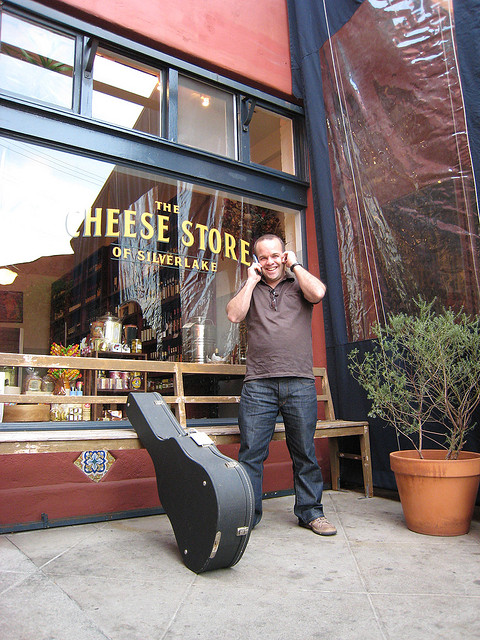

In [30]:
# I want to find the file based on the imid
imid = 207634
path = f"/research/hal-afsharim/learn-to-steer/data/pope/descriptive_test/images/COCO_val2014_{imid:012d}.jpg"
print(path)
# display(Image(l2s_descriptive["images"][i][0], width=400))
display(Image(path, width=400))
# pprint(l2s_descriptive["predictions"][i][0],width=150)
# pprint(reparo_descriptive["predictions"][i][0],width=150)
# display the image


In [ ]:
COCO_OBJECTS = set(id_to_name.values())
COCO_OBJECTS

In [ ]:
import spacy

nlp = spacy.load("en_core_web_sm")

def extract_objects(caption):
    doc = nlp(caption.lower())

    objects = set()

    for token in doc:
        # only nouns
        if token.pos_ in ["NOUN", "PROPN"]:
            lemma = token.lemma_

            if lemma in COCO_OBJECTS:
                objects.add(lemma)

    return objects

In [36]:
import spacy
nlp = spacy.load("en_core_web_sm")

SYNONYMS = {
    # Person / People
    "man": "person",
    "woman": "person",
    "boy": "person",
    "girl": "person",
    "child": "person",
    "kid": "person",
    "baby": "person",
    "guy": "person",
    "lady": "person",
    "gentleman": "person",
    "male": "person",
    "female": "person",
    "player": "person",
    "skater": "person",
    "skier": "person",
    "snowboarder": "person",
    "surfer": "person",
    "rider": "person",
    "driver": "person",
    "passenger": "person",
    "cop": "person",
    "police": "person",
    "pedestrian": "person",
    "people": "person",
    
    # Vehicles
    "bike": "bicycle",
    "cycle": "bicycle",
    "automobile": "car",
    "cab": "car",
    "taxi": "car",
    "suv": "car",
    "van": "car",
    "motorbike": "motorcycle",
    "moped": "motorcycle",
    "dirtbike": "motorcycle",
    "plane": "airplane",
    "jet": "airplane",
    "aircraft": "airplane",
    "airliner": "airplane",
    "minibus": "bus",
    "pickup": "truck",
    "lorry": "truck",
    "tractor": "truck",
    "ship": "boat",
    "ferry": "boat",
    "yacht": "boat",
    "canoe": "boat",
    "kayak": "boat",
    "sailboat": "boat",
    
    # Animals
    "pigeon": "bird",
    "seagull": "bird",
    "gull": "bird",
    "duck": "bird",
    "swan": "bird",
    "goose": "bird",
    "parrot": "bird",
    "eagle": "bird",
    "owl": "bird",
    "pelican": "bird",
    "kitten": "cat",
    "kitty": "cat",
    "feline": "cat",
    "puppy": "dog",
    "pup": "dog",
    "hound": "dog",
    "canine": "dog",
    "pony": "horse",
    "foal": "horse",
    "stallion": "horse",
    "mare": "horse",
    "lamb": "sheep",
    "ewe": "sheep",
    "ram": "sheep",
    "calf": "cow", # spaCy lemmatizes 'calves' to 'calf'
    "bull": "cow",
    "cattle": "cow",
    "ox": "cow",
    "cub": "bear",
    "grizzly": "bear",
    "panda": "bear",
    "polar": "bear",
    
    # Accessories & Luggage
    "knapsack": "backpack",
    "rucksack": "backpack",
    "pack": "backpack",
    "parasol": "umbrella",
    "purse": "handbag",
    "bag": "handbag",
    "pocketbook": "handbag",
    "necktie": "tie",
    "luggage": "suitcase",
    "baggage": "suitcase",
    "trunk": "suitcase",
    
    # Sports Equipment
    "ball": "sports ball",
    "football": "sports ball",
    "soccer": "sports ball",
    "basketball": "sports ball",
    "baseball": "sports ball",
    "volleyball": "sports ball",
    "tennis": "sports ball",
    "racket": "tennis racket",
    "racquet": "tennis racket",
    
    # Kitchen & Dining
    "flask": "bottle",
    "jug": "bottle",
    "thermos": "bottle",
    "wineglass": "wine glass",
    "goblet": "wine glass",
    "mug": "cup",
    "teacup": "cup",
    "coffee": "cup", # Frequently used as "a cup of coffee"
    
    # Furniture
    "sofa": "couch",
    "settee": "couch",
    "loveseat": "couch",
    "plant": "potted plant",
    "houseplant": "potted plant",
    "pot": "potted plant",
    "table": "dining table",
    "desk": "dining table",
    
    # Electronics & Appliances
    "television": "tv",
    "screen": "tv",
    "monitor": "tv",
    "computer": "laptop",
    "pc": "laptop",
    "macbook": "laptop",
    "notebook": "laptop",
    "phone": "cell phone",
    "cellphone": "cell phone",
    "mobile": "cell phone",
    "smartphone": "cell phone",
    "fridge": "refrigerator",
    "freezer": "refrigerator",
    
    # Miscellaneous
    "teddy": "teddy bear"
}

def normalize(word):
    return SYNONYMS.get(word, word)

def extract_objects(caption, coco_objects):
    doc = nlp(caption.lower())
    objects = set()

    for token in doc:   # <-- token is defined here
        if token.pos_ in ["NOUN", "PROPN"]:
            lemma = normalize(token.lemma_)  # <-- valid usage
            if lemma in coco_objects:
                objects.add(lemma)

    return objects

In [37]:
def compute_chair(pred_objects, gt_objects):
    hallucinated = pred_objects - gt_objects

    if len(pred_objects) == 0:
        chair_i = 0.0
    else:
        chair_i = len(hallucinated) / len(pred_objects)

    chair_s = 1 if len(hallucinated) > 0 else 0

    return chair_i, chair_s

In [ ]:
# save data["predictions"][i][0] and # find the basename of the image path
os.path.basename(data["images"][0][0])
# find the image id from the basename
image_id = int(os.path.basename(data["images"][0][0]).split(".")[0].split("_")[-1])
# image_id so that I can load them by predictions.items()
for i in range(len(data["predictions"])):
    
data["predictions"][i][0]

In [33]:

for data in [l2s_descriptive, reparo_descriptive]:
    total_hallucinated = 0
    total_predicted = 0
    total_sentences = 0
    sent_with_hallucination = 0

    for i in range(len(data["predictions"])):
        caption = data["predictions"][i][0]
        img_id = int(os.path.basename(data["images"][i][0]).split(".")[0].split("_")[-1])

        pred_objs = extract_objects(caption, COCO_OBJECTS)
        gt_objs = gt_objects[img_id]

        hallucinated = pred_objs - gt_objs

        total_hallucinated += len(hallucinated)
        total_predicted += len(pred_objs)

        if len(hallucinated) > 0:
            sent_with_hallucination += 1

        total_sentences += 1

    CHAIR_i = total_hallucinated / total_predicted
    CHAIR_s = sent_with_hallucination / total_sentences

    print(f"CHAIR_i: {CHAIR_i:.4f}")
    print(f"CHAIR_s: {CHAIR_s:.4f}")

CHAIR_i: 0.2704
CHAIR_s: 0.3300
CHAIR_i: 0.3394
CHAIR_s: 0.4720


In [43]:
import os
import spacy

# Assuming nlp, COCO_OBJECTS, gt_objects, and normalize() are already defined in your environment
# nlp = spacy.load("en_core_web_sm")
for data in [l2s_descriptive, reparo_descriptive]:
    total_hallucinated_instances = 0
    total_predicted_instances = 0
    total_sentences = 0
    hallucinated_sentences_count = 0

    for i in range(len(data["predictions"])):
        caption = data["predictions"][i][0]
        # Extract image_id safely
        basename = os.path.basename(data["images"][i][0])
        img_id = int(basename.split(".")[0].split("_")[-1])
        
        gt_objs = gt_objects[img_id]

        # Process the entire caption text
        doc = nlp(caption.lower())
        
        # Iterate through sentences generated by the model
        for sent in doc.sents:
            total_sentences += 1
            sent_has_hallucination = False
            
            # Iterate through tokens within the specific sentence
            for token in sent:
                if token.pos_ in ["NOUN", "PROPN"]:
                    lemma = normalize(token.lemma_) 
                    
                    # Check if the token maps to a valid MSCOCO class
                    if lemma in COCO_OBJECTS:
                        total_predicted_instances += 1
                        
                        # Check against ground truth
                        if lemma not in gt_objs:
                            total_hallucinated_instances += 1
                            sent_has_hallucination = True
                            
            # If any token in this sentence was a hallucination, mark the sentence
            if sent_has_hallucination:
                hallucinated_sentences_count += 1

    # Calculate final metrics with zero-division safeguards
    CHAIR_i = (total_hallucinated_instances / total_predicted_instances) if total_predicted_instances > 0 else 0.0
    CHAIR_s = (hallucinated_sentences_count / total_sentences) if total_sentences > 0 else 0.0
    print("")
    print(f"Total Sentences: {total_sentences}")
    print(f"Total Predicted MSCOCO Instances: {total_predicted_instances}")
    print(f"Total Hallucinated Instances: {total_hallucinated_instances}")
    print(f"CHAIR_i: {CHAIR_i:.4f}")
    print(f"CHAIR_s: {CHAIR_s:.4f}")


Total Sentences: 2208
Total Predicted MSCOCO Instances: 2903
Total Hallucinated Instances: 570
CHAIR_i: 0.1963
CHAIR_s: 0.1975

Total Sentences: 2319
Total Predicted MSCOCO Instances: 3164
Total Hallucinated Instances: 708
CHAIR_i: 0.2238
CHAIR_s: 0.2342


data variable: {data_variable_name}


In [ ]:
pprint(caption)
display(Image(data["images"][i][0]))

In [ ]:
import json

# reparo = "/research/hal-afsharim/learn-to-steer/Hallucination/POPE/hallucination/hallucination_metrics_llava_pope_test_reparo_14_yes_no_popular_5_-0.035_-0.04_spca_model_llava_14_all_pope_train_-1_model_prediction.json"
# l2s = "/research/hal-afsharim/learn-to-steer/Hallucination/POPE/hallucination/hallucination_metrics_llava_pope_test_steer_14_yes_no_popular_2.2_llava_14_average_all_pope_train_-1_model_prediction.json"

reparo = "/research/hal-afsharim/learn-to-steer/Hallucination/POPE/hallucination/hallucination_metrics_llava_pope_test_reparo_14_yes_no_random_5_-0.05_-0.08_spca_model_llava_14_all_pope_train_-1_model_prediction.json"
l2s= "/research/hal-afsharim/learn-to-steer/Hallucination/POPE/hallucination/hallucination_metrics_llava_pope_test_steer_14_yes_no_random_2.2_llava_14_average_all_pope_train_-1_model_prediction.json"
no_steer = "/research/hal-afsharim/learn-to-steer/Hallucination/POPE/hallucination/hallucination_metrics_llava_pope_test_eval_no_steer_random_-1_model_prediction.json"
with open(reparo,"r") as f:
    reparo = json.load(f)

with open(l2s,"r") as f:
    l2s = json.load(f)

with open(no_steer,"r") as f:
    no_steer = json.load(f)


In [ ]:
l2s.keys()

In [ ]:
len(reparo["response"]), len(l2s["predictions"]), len(no_steer["predictions"])

In [ ]:
diff = []
for i in range(len(no_steer["predictions"])):
    # if not l2s["predictions"][i][0].lower()[:5] == reparo["predictions"][i][0].lower()[:5]:
    if not no_steer["predictions"][i][0].lower()[:5] == reparo["predictions"][i][0].lower()[:5]:
        diff.append(i)

In [ ]:
import matplotlib.pyplot as plt
from pprint import pprint
for i in diff[31:60]:
    print("L2S:", end=" ") # Label on the same line
    pprint(l2s["predictions"][i][0])
    
    print("REPARO:", end=" ")
    pprint(reparo["predictions"][i][0])
    
    print("No Steer:",end=" ")
    pprint(no_steer["predictions"][i][0])
    pprint(no_steer["response"][i][0])
    img = plt.imread(reparo["images"][i][0])
    plt.imshow(img)
    plt.axis('off')  # optional, removes axes
    plt.show()

In [ ]:
diff